<a href="https://colab.research.google.com/github/saikrishnanallavula/Final-year-project-Sai-Krishna-Nallavula/blob/main/TB_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
Path to dataset files: /kaggle/input/tuberculosis-tb-chest-xray-dataset


Loading Tuberculosis: 100%|██████████| 700/700 [00:09<00:00, 70.35it/s]


Class Distribution:
Normal: 3500 images
Tuberculosis: 700 images
All images have the same shape: {(224, 224, 3)}


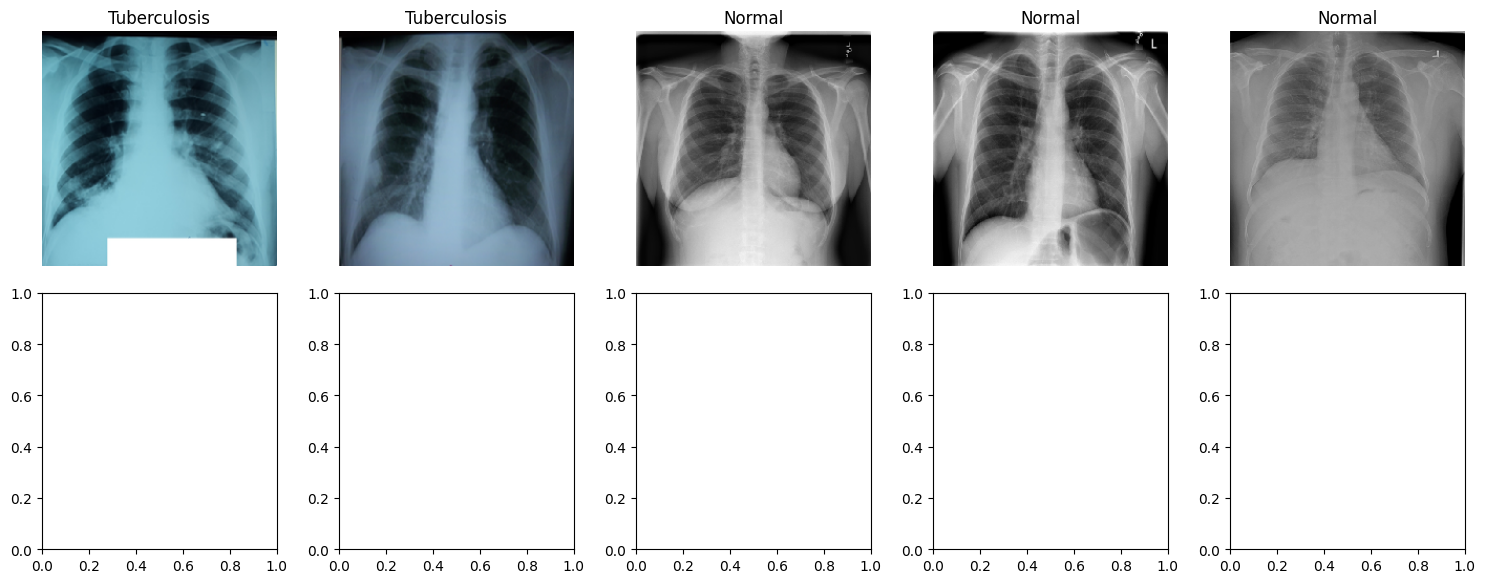

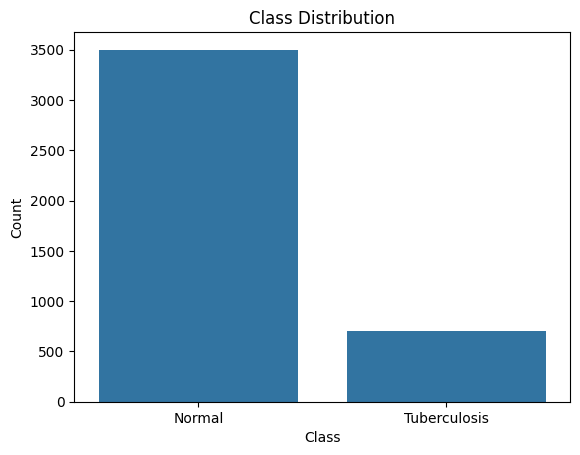

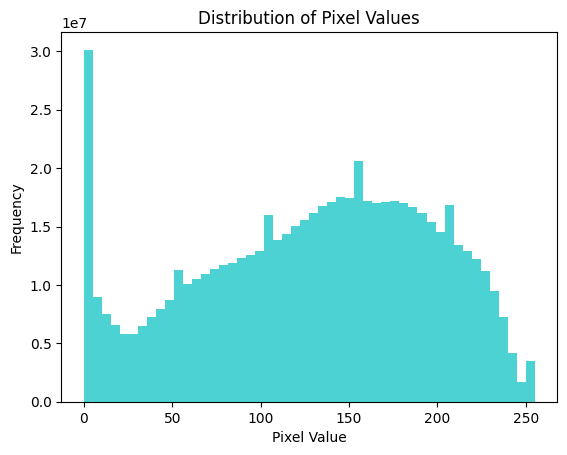

Mean Pixel Value: 129.54, Standard Deviation: 66.37


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from pathlib import Path
from tqdm import tqdm

# Dataset path and label mapping
path = Path('/kaggle/input/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database')
label_map = {
    'Normal': 0,
    'Tuberculosis': 1
}

# List to hold images and labels
images = []
labels = []

# Loading images and labels
for class_name, label in label_map.items():
    class_dir = path / class_name
    for img_path in tqdm(list(class_dir.iterdir()), desc=f"Loading {class_name}"):
        img = load_img(img_path, target_size=(224, 224))  # Resize to 224x224
        img = img_to_array(img)  # Convert image to numpy array
        images.append(img)
        labels.append(label)

images = np.array(images, dtype='float32')
labels = np.array(labels, dtype='int32')

# 1. Check Class Distribution
class_counts = {class_name: sum(np.array(labels) == label) for class_name, label in label_map.items()}
print("Class Distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

# 2. Check Image Shape Consistency
image_shapes = [img.shape for img in images]
unique_shapes = set(image_shapes)

if len(unique_shapes) == 1:
    print("All images have the same shape:", unique_shapes)
else:
    print("Images have varying shapes:", unique_shapes)

# 3. Visualize Sample Images from the Dataset
def plot_sample_images(images, labels, label_map, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    axes = axes.ravel()

    # Randomly sample indices
    sample_indices = np.random.choice(range(len(images)), size=num_samples*2, replace=False)

    for i, idx in enumerate(sample_indices[:num_samples]):
        axes[i].imshow(images[idx] / 255.0)  # Normalize image to [0, 1] range
        axes[i].set_title(f"{list(label_map.keys())[labels[idx]]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Plot 5 sample images
plot_sample_images(images, labels, label_map, num_samples=5)

# 4. Check for Class Imbalance
sns.countplot(x=labels)
plt.xticks([0, 1], ['Normal', 'Tuberculosis'], rotation=0)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 5. Analyze Pixel Value Distribution
pixel_values = np.concatenate(images, axis=0).flatten()
plt.hist(pixel_values, bins=50, color='c', alpha=0.7)
plt.title("Distribution of Pixel Values")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# Optionally, compute mean and standard deviation of pixel values
mean_pixel_value = np.mean(pixel_values)
std_pixel_value = np.std(pixel_values)
print(f"Mean Pixel Value: {mean_pixel_value:.2f}, Standard Deviation: {std_pixel_value:.2f}")
